MinMaxScaler

StandardScaler

RobustScaler

In [119]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [92]:
df=pd.read_csv('train.csv')

In [93]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# df['Sex']=df[df['Sex']=='male'].astype(int)
# df['Sex']=pd.get_dummies(df['Sex'])
# Convert 'male' to 1 and 'female' to 0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

In [110]:

X=df[['Age']]
Y=df[['Salary']]

In [27]:
# Simple fill with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

In [85]:
df.isnull().sum()

Age       0
Salary    0
dtype: int64

In [29]:
df['Sex'].value_counts()

Series([], Name: count, dtype: int64)

In [30]:
X_train.shape



(623, 3)

In [31]:
Y_test.shape

(268, 1)

In [86]:
df

,Age,Salary
0,18,20000
1,22,30000
2,25,40000
3,30,60000
4,35,80000
5,40,100000
6,45,120000
7,50,150000


In [108]:
df = pd.DataFrame({
    'Age':[18,22,25,30,35,40,45,50],
    'Salary':[20000,30000,40000,60000,80000,100000,120000,150000]
})


In [111]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=0)

<Axes: xlabel='Age', ylabel='Salary'>

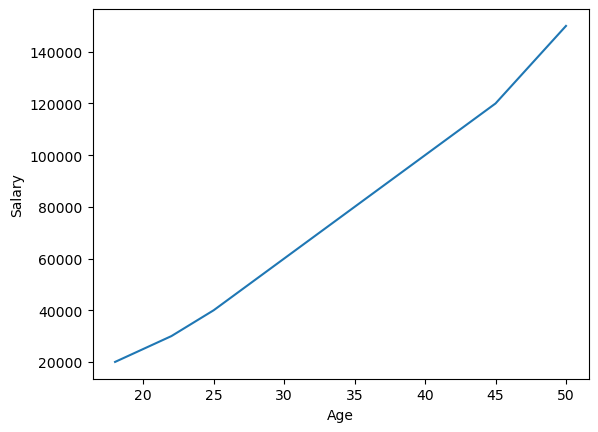

In [112]:
sns.lineplot(x='Age',y='Salary',data=df)

In [97]:
df.describe()

,Age,Salary
count,8.000000,8.000000
mean,33.125000,75000.000000
std,11.369602,45981.362684
min,18.000000,20000.000000
25%,24.250000,37500.000000
50%,32.500000,70000.000000
75%,41.250000,105000.000000
max,50.000000,150000.000000


In [120]:
scaler=StandardScaler()

In [52]:
scaled=scaler.fit_transform(df)

In [53]:
scaled

array([[-1.42215221, -1.27872403],
       [-1.04604584, -1.04622875],
       [-0.76396607, -0.81373347],
       [-0.2938331 , -0.34874292],
       [ 0.17629986,  0.11624764],
       [ 0.64643282,  0.58123819],
       [ 1.11656579,  1.04622875],
       [ 1.58669875,  1.74371458]])

In [54]:
scaler_df=pd.DataFrame(scaled,columns=df.columns)

In [55]:
scaler_df

,Age,Salary
0,-1.422152,-1.278724
1,-1.046046,-1.046229
2,-0.763966,-0.813733
3,-0.293833,-0.348743
4,0.176300,0.116248
5,0.646433,0.581238
6,1.116566,1.046229
7,1.586699,1.743715


In [56]:
from sklearn.preprocessing import MinMaxScaler

In [57]:
mm=MinMaxScaler()

In [59]:
mms=mm.fit_transform(df)

In [60]:
mms

array([[0.        , 0.        ],
       [0.125     , 0.07692308],
       [0.21875   , 0.15384615],
       [0.375     , 0.30769231],
       [0.53125   , 0.46153846],
       [0.6875    , 0.61538462],
       [0.84375   , 0.76923077],
       [1.        , 1.        ]])

In [61]:
mms=pd.DataFrame(mms,columns=df.columns)

In [62]:
mms

,Age,Salary
0,0.00000,0.000000
1,0.12500,0.076923
2,0.21875,0.153846
3,0.37500,0.307692
4,0.53125,0.461538
5,0.68750,0.615385
6,0.84375,0.769231
7,1.00000,1.000000


In [67]:
df

,Age,Salary
0,18,20000
1,22,30000
2,25,40000
3,30,60000
4,35,80000
5,40,100000
6,45,120000
7,50,150000


In [68]:
df.loc[8] = [60,1000000]

In [103]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled,
    columns=df.columns
)

scaled_df

,Age,Salary
0,-0.852941,-0.740741
1,-0.617647,-0.592593
2,-0.441176,-0.444444
3,-0.147059,-0.148148
4,0.147059,0.148148
5,0.441176,0.444444
6,0.735294,0.740741
7,1.029412,1.185185


In [115]:
X_train.shape,Y_train.shape

((5, 1), (5, 1))

In [123]:
new_x=scaler.fit_transform(X_train)

In [114]:
X_train.isnull().sum()

Age    0
dtype: int64

In [124]:
scaler.mean_

array([34.6])